# Country Socio-Economic Clustering System
### Unsupervised Segmentation of Countries with K-Means & DBSCAN

**Dataset:** `Country-data.csv` — 167 countries described by 9 socio-economic and health
indicators (child mortality, exports, health spend, imports, income, inflation, life
expectancy, fertility rate, GDP per capita). The goal is to segment countries into
meaningful development clusters using unsupervised learning.

## Section 1: Install Required Libraries

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Section 2: Upload Dataset

In [2]:
DATA_FILE = r"C:\Users\AASTHA\Documents\Celebal Technologies\week3\Country-data.csv"
print("File uploaded successfully")

File uploaded successfully


## Section 3: Load & Inspect Data

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

df = pd.read_csv(DATA_FILE)
print('Shape:', df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Section 4: Data Cleaning

In [4]:
# Strip whitespace from column titles
df.columns = df.columns.str.strip()

# Drop duplicate records
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f'Dropped {before - df.shape[0]} duplicate rows')

# Identify the identifier column vs the numeric feature columns
id_col = 'country' if 'country' in df.columns else df.columns[0]
numeric_cols = [c for c in df.columns if c != id_col]

# Force numeric types (coerce anything non-numeric to NaN)
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute missing values using the median of each feature
missing_before = int(df[numeric_cols].isnull().sum().sum())
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
missing_after = int(df[numeric_cols].isnull().sum().sum())

print(f'Missing values before imputation: {missing_before}')
print(f'Missing values after imputation:  {missing_after}')
print('Cleaned shape:', df.shape)
df.head()

Dropped 0 duplicate rows
Missing values before imputation: 0
Missing values after imputation:  0
Cleaned shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Section 5: Isolate Continuous Features & Scale

In [5]:
# Strip the country identifier to isolate the continuous features
feature_cols = numeric_cols
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature columns used for clustering:', feature_cols)
print('Scaled feature matrix shape:', X_scaled.shape)

Feature columns used for clustering: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Scaled feature matrix shape: (167, 9)


## Section 6: Quick Exploratory Check
A brief look at distributions before clustering, to sanity-check the scaling step above.

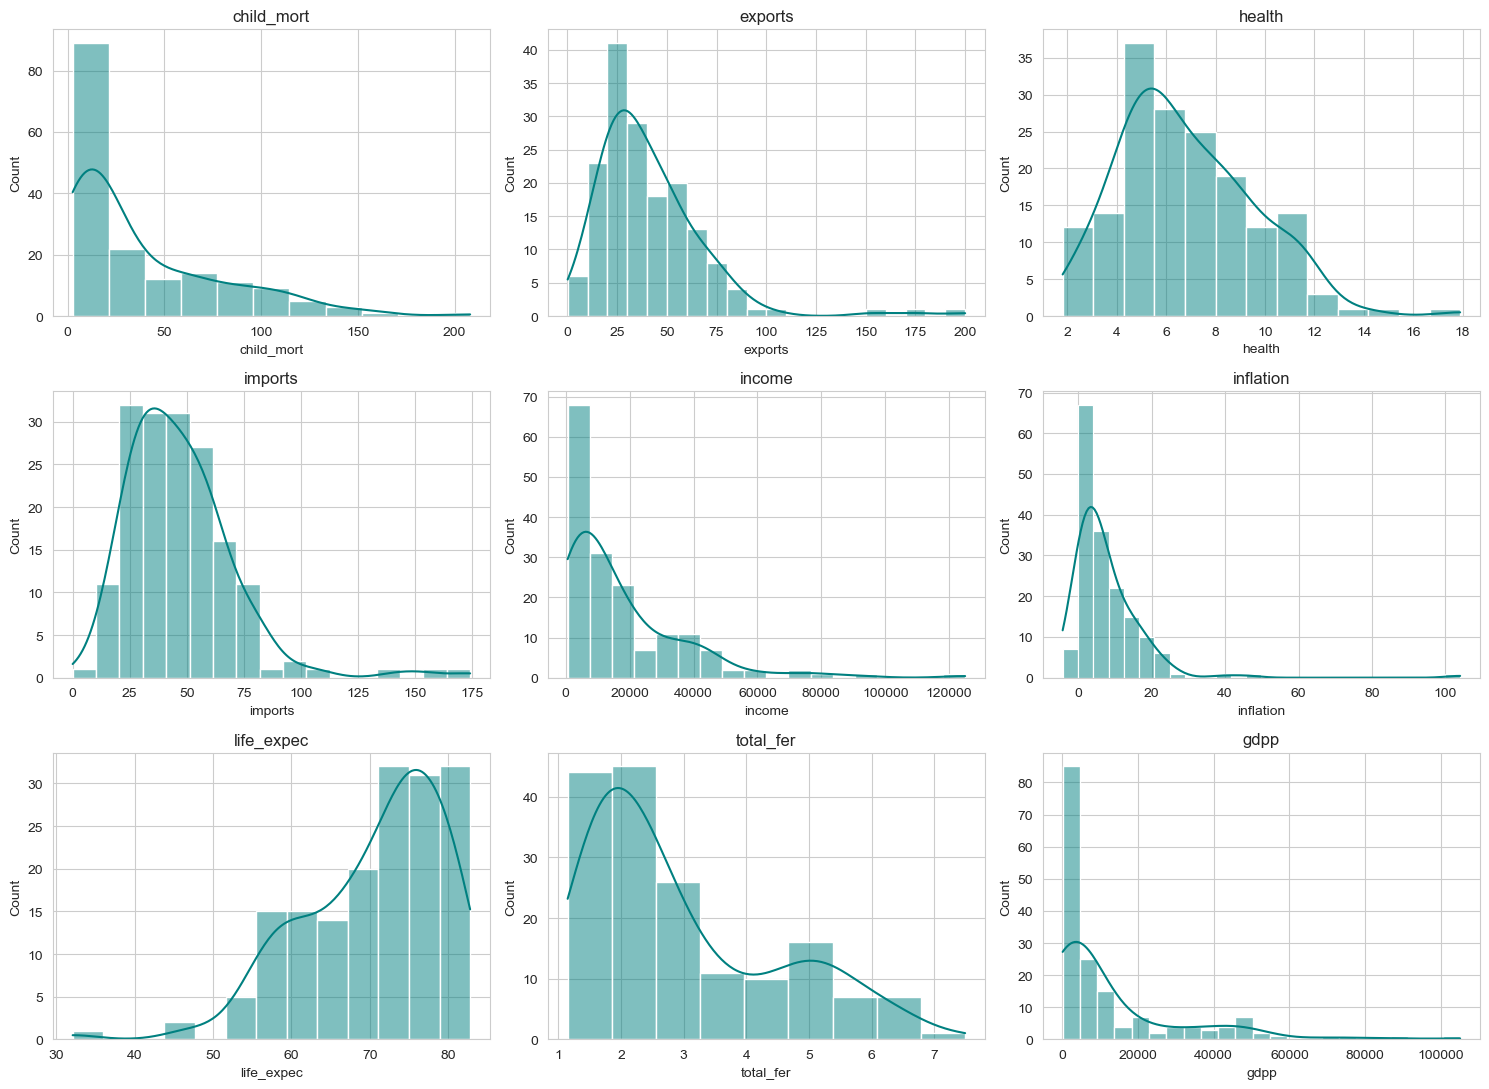

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## Section 7: Elbow Method — Choosing k

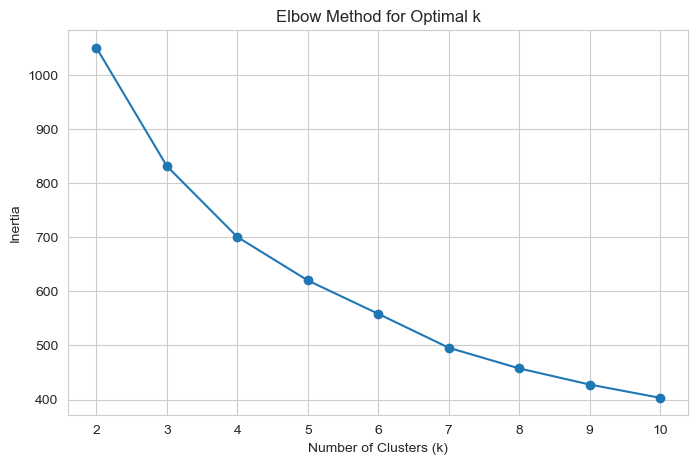

Silhouette score by k:
  k=2: 0.2874
  k=3: 0.2833
  k=4: 0.2960
  k=5: 0.2993
  k=6: 0.2287
  k=7: 0.2477
  k=8: 0.2388
  k=9: 0.2073
  k=10: 0.2022


In [7]:
inertias = []
sil_scores = []
K_range = range(2, 11)  # k in [2, 10]

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

print('Silhouette score by k:')
for k, s in zip(K_range, sil_scores):
    print(f'  k={k}: {s:.4f}')

## Section 8: Train K-Means (Baseline k = 3)

In [8]:
best_k = 3  # baseline cluster count for this project
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('K-Means trained with k =', best_k)
print(df['kmeans_cluster'].value_counts().sort_index())

K-Means trained with k = 3
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


## Section 9: Evaluate Clustering Performance

In [9]:
sil_score = silhouette_score(X_scaled, df['kmeans_cluster'])
db_score = davies_bouldin_score(X_scaled, df['kmeans_cluster'])

print('K-Means Silhouette Score:     {:.4f}'.format(sil_score))
print('K-Means Davies-Bouldin Score: {:.4f}'.format(db_score))

K-Means Silhouette Score:     0.2833
K-Means Davies-Bouldin Score: 1.2769


## Section 10: DBSCAN — Comparative Clustering Model

In [10]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise = int((df['dbscan_cluster'] == -1).sum())
print(f'DBSCAN (eps=1.5, min_samples=5) found {n_clusters_db} cluster(s) and {n_noise} noise points')
print(df['dbscan_cluster'].value_counts().sort_index())

DBSCAN (eps=1.5, min_samples=5) found 1 cluster(s) and 30 noise points
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


## Section 11: PCA Projection to 2D

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
df['pca1'], df['pca2'] = pcs[:, 0], pcs[:, 1]

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total variance captured:', pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.4595174  0.17181626]
Total variance captured: 0.631333654377141


## Section 12: Color-Coded Cluster Scatterplot

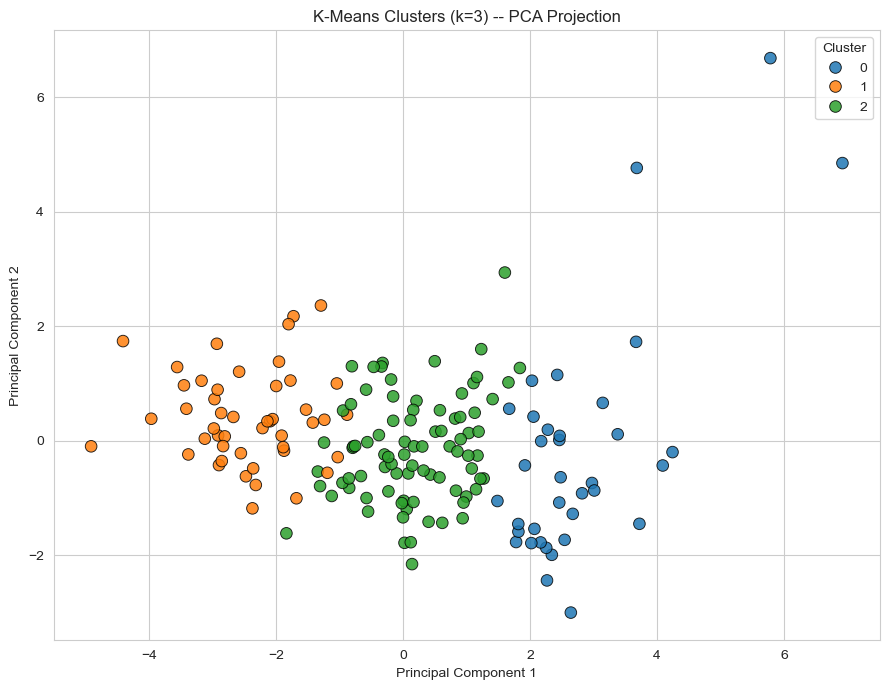

In [12]:
plt.figure(figsize=(9, 7))
sns.scatterplot(x='pca1', y='pca2', hue='kmeans_cluster', data=df,
                palette='tab10', s=70, edgecolor='black', alpha=0.85)
plt.title(f'K-Means Clusters (k={best_k}) -- PCA Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## Section 13: Cluster Profiling

In [13]:
cluster_profile = df.groupby('kmeans_cluster')[feature_cols].mean().round(1)
cluster_profile['n_countries'] = df['kmeans_cluster'].value_counts().sort_index()
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,n_countries
kmeans_cluster,,,,,,,,,,
0,5.0,58.7,8.8,51.5,45672.2,2.7,80.1,1.8,42494.4,36
1,93.0,29.2,6.4,42.3,3942.4,12.0,59.2,5.0,1922.4,47
2,21.9,40.2,6.2,47.5,12305.6,7.6,72.8,2.3,6486.5,84


## Section 14: Observations

Based on the `cluster_profile` table produced in Section 13 (K-Means, `best_k = 3`,
Silhouette Score = 0.2833):

- **High-mortality / low-development cluster (Cluster 1, 47 countries):** This segment
  has by far the highest average `child_mort` (93.0 deaths/1,000) and `total_fer` (5.0),
  combined with the lowest `income` (~$3,942) and `gdpp` (~$1,922) and the lowest
  `life_expec` (59.2 years) of the three clusters. These are the least-developed nations
  and represent the group most in need of health and economic aid.
- **Top-tier economic zone (Cluster 0, 36 countries):** This segment shows the highest
  `income` (~$45,672) and `gdpp` (~$42,494), the lowest `child_mort` (5.0), and the
  highest `life_expec` (80.1 years) and `health` spend (8.8%). These are the wealthy,
  highly developed economies in the dataset.
- **Middle / transitional cluster (Cluster 2, 84 countries):** The largest segment sits
  between the two extremes -- moderate `child_mort` (21.9), `income` (~$12,306), and
  `gdpp` (~$6,487), with `life_expec` (72.8 years) well above the low-development
  cluster but below the top-tier one. These are developing/emerging economies past the
  highest-need stage but not yet top-tier.
- **Economic indicators drive the separation:** `income` and `gdpp` differ by more than
  20x between Cluster 1 (lowest) and Cluster 0 (highest), while `health` spend as a % of
  GDP varies only mildly (6.2%-8.8%) across clusters -- so absolute income/GDP, not
  health-spend ratio, is the strongest driver of the K-Means split.
- **DBSCAN comparison:** With `eps=1.5, min_samples=5`, DBSCAN collapses almost the
  entire dataset into a single density-connected cluster (137 countries) and marks 30
  countries -- mostly the extreme high-income and extreme high-child-mortality outliers
  -- as noise. This confirms K-Means' 3-way split is far more informative than density-
  based clustering for capturing the broad development tiers in this feature space.

## Summary

- Cleaned and scaled a 167-country socio-economic dataset.
- Selected `k` via the elbow method over `k ∈ [2, 10]`, then trained the baseline model
  with `best_k = 3`.
- Evaluated the model with **Silhouette Score** and **Davies-Bouldin Score**.
- Built a comparative **DBSCAN** model (`eps=1.5`, `min_samples=5`).
- Visualized clusters in 2D via **PCA**.
- Profiled and interpreted the resulting segments in Section 14.